моя нейронная сеть с одним скрытым слоем для распознавая цифр со свтроенного датасета sklearn

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
digits = load_digits()
y = digits.target
X = digits.data.reshape(-1, 64, 1)
print(X.shape)
print(y.shape)
print(X[0].shape)
print(len(X))

y = np.eye(10)[y]


(1797, 64, 1)
(1797,)
(64, 1)
1797


In [3]:
def draw(X):
    matrix = X.reshape(8,8)
    plt.imshow(matrix, cmap='gray')
    plt.axis('off')
    plt.show()


In [4]:
class MyNeurNet:
    def __init__(self, arch, learning_rate=0.01, n_iters=1000):
        np.random.seed(42)
        self.learning_rate=learning_rate
        self.n_iters=n_iters
        self.W = []
        self.B = []
        for i in range(len(arch)-1):
            curr_lay = arch[i]
            next_lay = arch[i+1]
            
            scale = 1/np.sqrt(curr_lay)
            curr_w = np.random.randn(curr_lay, next_lay) * scale
            curr_b = np.zeros((1, next_lay))

            self.W.append(curr_w)
            self.B.append(curr_b)
    
    def sigmoid(self, z):
        return 1/(1+np.exp(-z))
    
    def der_sigmoid(self, z):
        return self.sigmoid(z)*(1-self.sigmoid(z))
    
    def predict_for_lay(self, x, w, b):
        return self.sigmoid(x @ w + b)
    
    def predict_for_layers(self, X):
        S = []
        A = []
        Z = []
        A.append(X)
        for i in range(len(self.W)):
            X = X @ self.W[i] + self.B[i]
            S.append(X)
            Z.append(self.der_sigmoid(X))
            X = self.sigmoid(X)
            A.append(X)
        return S, A, Z
    
    def predict(self, x):
        x = x.T
        for i in range(len(self.W)):
            x = self.predict_for_lay(x, self.W[i], self.B[i])
        return x

    def lay_loss_on_object(self, x, y):
        x = self.predict(x)
        return x - y

    def sum_loss_on_object(self, x, y):
        x_pred = self.predict(x)
        loss = 0.0
        for i in range(len(y)):
            loss += ((x_pred[i] - y[i])**2)/0.5
        return loss

    def fit(self, X, y):
        np.random.RandomState(42)
        for i in range(self.n_iters):
            index = np.random.randint(0, len(X))
            S = []  #результат w[i]x[i] + b
            A = []  #sigmoid(S)
            Z = []  #dersigmoid(S)
            S, A, Z = self.predict_for_layers(X[index].T)
            loss = self.lay_loss_on_object(X[index], y[index])
            for j in range(len(self.W) - 1, -1, -1):
                # print(f"loss: {loss.shape}")
                # print(f"Z[j]: {Z[j].shape}")
                # print(f"A[j]: {A[j].shape}")
                # print(f"B[j]: {self.B[j].shape}")
                # print(f"W[j]: {self.W[j].shape}")
                dw = A[j].T @ (loss * Z[j])
                self.W[j] -= self.learning_rate * dw
                self.B[j] -= self.learning_rate * loss
                if j > 0:
                    loss = (loss @ self.W[j].T) * Z[j-1]


Пред: 8| Факт: 9


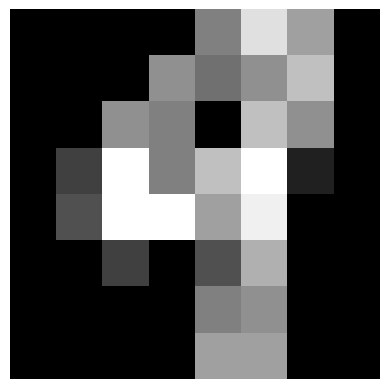

Пред: 7| Факт: 0


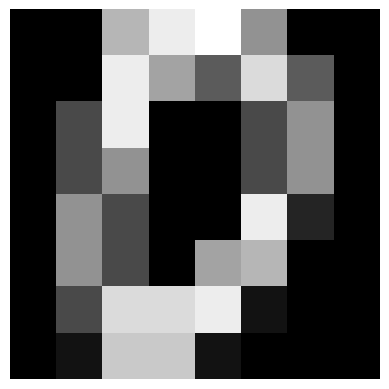

Пред: 9| Факт: 5


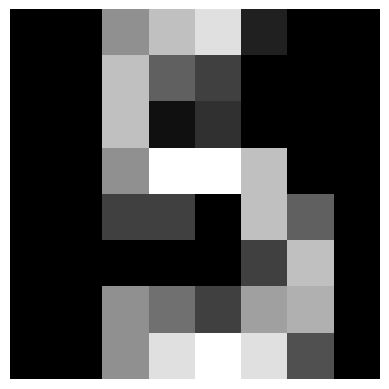

Пред: 9| Факт: 5


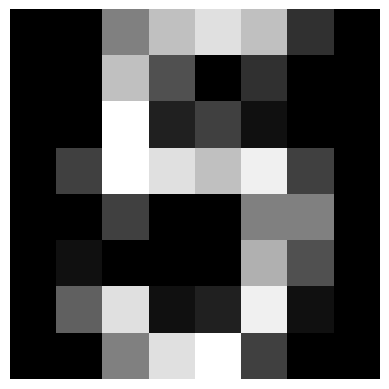

Пред: 4| Факт: 0


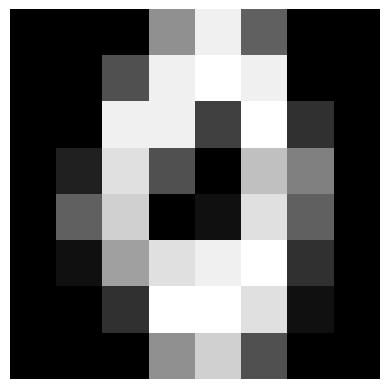

Пред: 8| Факт: 2


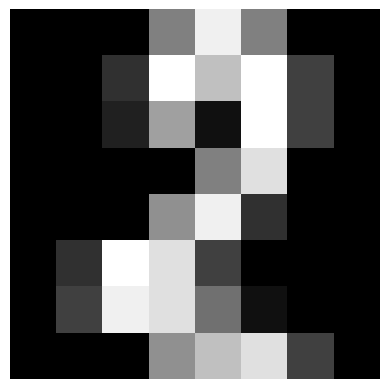

Пред: 9| Факт: 7


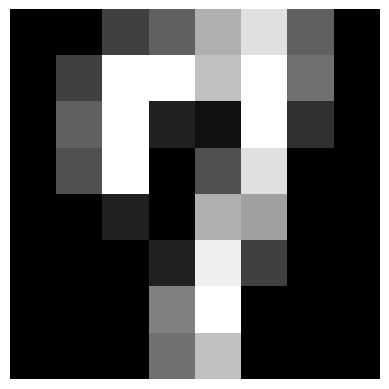

Пред: 7| Факт: 9


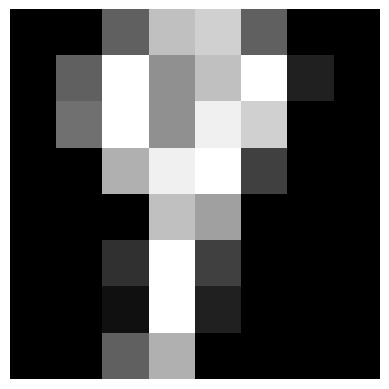

Пред: 7| Факт: 9


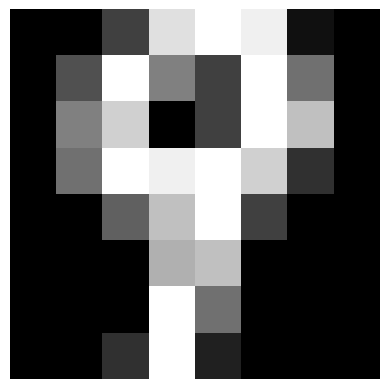

Пред: 1| Факт: 8


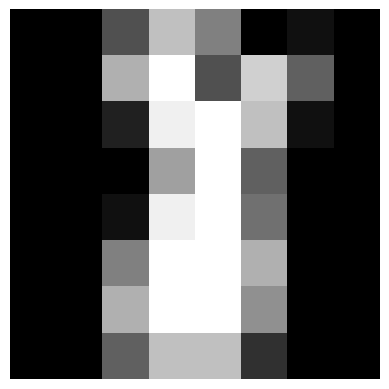

Пред: 9| Факт: 5


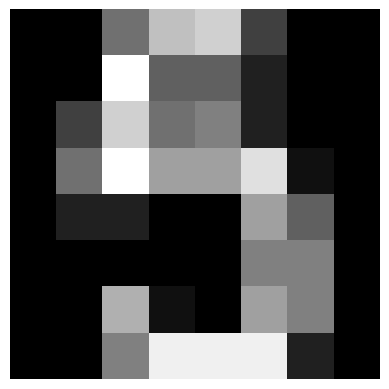

Пред: 0| Факт: 6


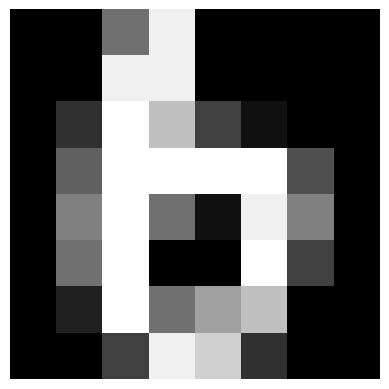

Пред: 8| Факт: 9


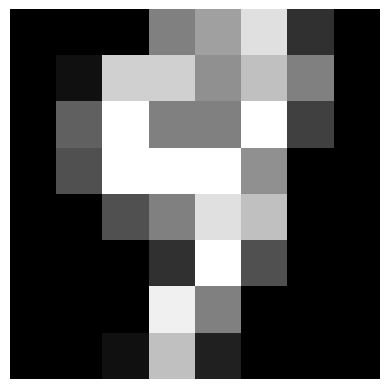

Пред: 5| Факт: 9


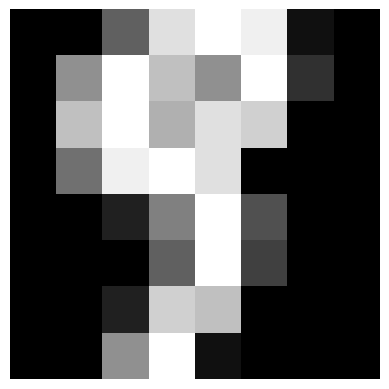

Пред: 2| Факт: 9


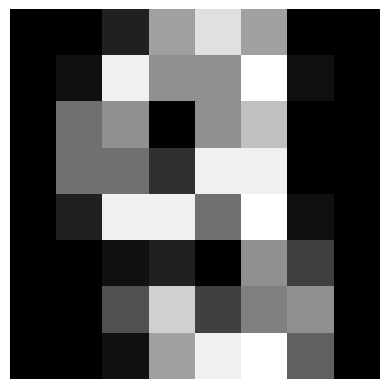

Пред: 5| Факт: 2


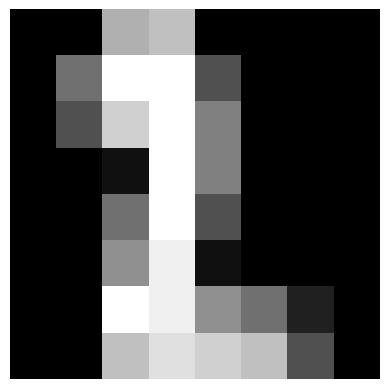

Пред: 1| Факт: 8


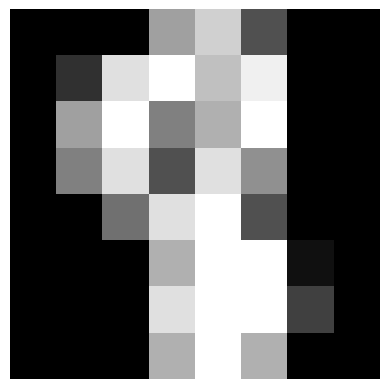

Пред: 6| Факт: 5


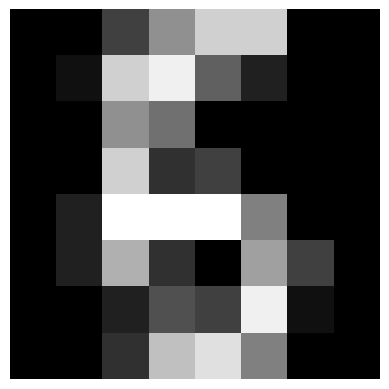

Пред: 1| Факт: 8


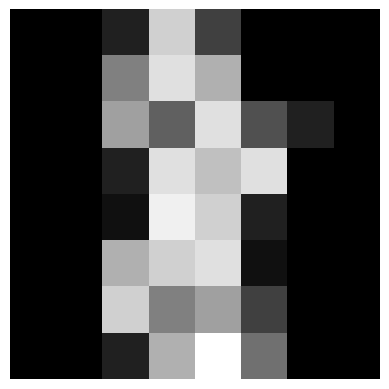

Пред: 8| Факт: 3


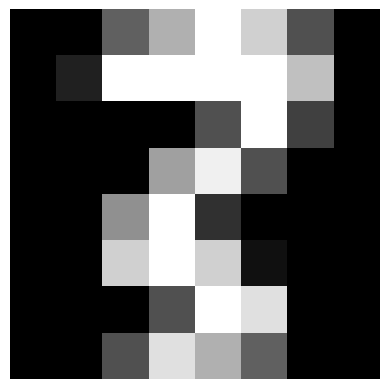

Всего: 450
Правильных: 430


In [10]:
mymodel = MyNeurNet (
    arch=[64, 18, 10],
    learning_rate=0.012,
    n_iters=25000
)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
mymodel.fit(X_train, y_train)
correct = 0
for i in range(len(y_test)):
    pred_pob = mymodel.predict(X_test[i])
    pred = np.argmax(pred_pob)
    if y_test[i][pred] == 1:
        correct += 1
    else:
        print(f"Пред: {pred}| Факт: {np.argmax(y_test[i])}")
        draw(X_test[i])

print(f"Всего: {len(y_test)}")
print(f"Правильных: {correct}")